# Reconnaissance d'entites nommees (NER) pour le Wolof

**Projet NLP — corpus MasakhaNER Wolof**

Ce notebook met en place un systeme de NER pour le wolof par *fine-tuning*
d'un transformer multilingue pre-entraine.

**Plan :**
1. **Phase 1 — Exploration** des donnees (comprendre le corpus)
2. **Phase 2 — Pipeline** (tokenization + alignement des labels sur les sous-mots)
3. **Phase 3 — Fine-tuning** *(a venir)*
4. **Phase 4 — Evaluation** au niveau entite (F1 via seqeval) *(a venir)*
5. **Phase 5 — Comparaison de modeles** *(a venir)*
6. **Phase 6 — Application Streamlit** *(a venir)*

> **Tache :** classification de tokens (*token classification*) avec schema
> **BIO**. Chaque mot recoit une etiquette parmi
> `O, B-PER, I-PER, B-LOC, I-LOC, B-DATE, I-DATE, B-ORG, I-ORG`.


## Phase 0 — Installation et donnees (Colab)

Executez cette cellule sur Colab pour installer les dependances. Puis
**televersez** les trois fichiers `train.txt`, `dev.txt`, `test.txt`
(menu fichiers de Colab, ou `files.upload()`).

Les fichiers sont au format **CoNLL** : un token et son etiquette par ligne
(separes par une tabulation ou un espace), phrases separees par une ligne vide.


In [ ]:
# --- Installations (Colab) ---
# !pip install -q -U transformers datasets seqeval evaluate accelerate huggingface_hub
# !pip uninstall -q -y hf_xet    # evite le backend Xet (source d'erreurs 403)


> **Important — contournement de l'erreur 403 Xet.**
> Le telechargement du modele peut echouer avec une erreur
> `403 Forbidden ... cas-bridge.xethub.hf.co`. C'est un probleme du CDN
> "Xet" de HuggingFace, pas du code. La cellule ci-dessous **desactive Xet**
> et doit etre executee **avant tout `import transformers`**.


In [1]:
import os
# Desactive le backend Xet AVANT d'importer transformers (corrige l'erreur 403)
os.environ["HF_HUB_DISABLE_XET"] = "1"

import statistics
from collections import Counter

# Verification de la presence des fichiers
for f in ["train.txt", "dev.txt", "test.txt"]:
    print(f, "->", "OK" if os.path.exists(f) else "MANQUANT")

# (Optionnel) s'authentifier pour eviter les limites de debit anonymes :
# from huggingface_hub import login
# login("hf_xxx")   # ton token depuis huggingface.co/settings/tokens


train.txt -> OK
dev.txt -> OK
test.txt -> OK


## Phase 1 — Exploration des donnees

Objectif : comprendre finement le corpus et recolter les chiffres qui
justifient nos choix techniques (et nourrissent la presentation).


### 1.1 — Le parseur CoNLL

Fonction socle reutilisee partout : elle transforme le fichier texte en une
liste de phrases `{"tokens": [...], "labels": [...]}`.


In [2]:
def read_conll(path):
    """Lit un fichier CoNLL -> liste de {"tokens": [...], "labels": [...]}."""
    sentences = []
    tokens, labels = [], []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if line.strip() == "":
                if tokens:
                    sentences.append({"tokens": tokens, "labels": labels})
                    tokens, labels = [], []
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            tokens.append(parts[0])
            labels.append(parts[-1])
    if tokens:
        sentences.append({"tokens": tokens, "labels": labels})
    return sentences


def extract_entities(labels):
    """Reconstruit les entites (type, debut, fin) a partir d'une sequence BIO.
    Sert a compter les VRAIES entites (niveau entite = ce qu'on evalue)."""
    entities, current, start = [], None, None
    for i, lab in enumerate(labels):
        if lab == "O":
            if current is not None:
                entities.append((current, start, i - 1)); current = None
        elif lab.startswith("B-"):
            if current is not None:
                entities.append((current, start, i - 1))
            current, start = lab[2:], i
        elif lab.startswith("I-"):
            t = lab[2:]
            if current != t:
                if current is not None:
                    entities.append((current, start, i - 1))
                current, start = t, i
        else:
            current = None
    if current is not None:
        entities.append((current, start, len(labels) - 1))
    return entities


data = {s: read_conll(f"{s}.txt") for s in ["train", "dev", "test"]}
print("Chargement termine.")

Chargement termine.


### 1.2 — Volume de chaque split

In [3]:
for s in ["train", "dev", "test"]:
    n_sent = len(data[s])
    n_tok = sum(len(x["tokens"]) for x in data[s])
    print(f"{s:5s} : {n_sent:5d} phrases | {n_tok:6d} tokens")

train :  1871 phrases |  36805 tokens
dev   :   267 phrases |   4384 tokens
test  :   539 phrases |  11682 tokens


### 1.3 — Distribution des etiquettes (niveau *token*)

On s'attend a un fort desequilibre : la classe `O` (mots hors entite) domine.


In [4]:
for s in ["train", "dev", "test"]:
    c = Counter(l for x in data[s] for l in x["labels"])
    total = sum(c.values())
    print(f"\n-- {s} -- (O = {100*c['O']/total:.1f}% des tokens)")
    for lab, n in c.most_common():
        print(f"   {lab:8s} {n:6d}  ({100*n/total:5.2f}%)")


-- train -- (O = 94.1% des tokens)
   O         34648  (94.14%)
   B-LOC       566  ( 1.54%)
   B-PER       522  ( 1.42%)
   I-PER       440  ( 1.20%)
   B-ORG       179  ( 0.49%)
   I-DATE      170  ( 0.46%)
   B-DATE      130  ( 0.35%)
   I-ORG       129  ( 0.35%)
   I-LOC        21  ( 0.06%)

-- dev -- (O = 96.5% des tokens)
   O          4231  (96.51%)
   B-LOC        59  ( 1.35%)
   B-PER        33  ( 0.75%)
   I-PER        28  ( 0.64%)
   B-ORG        11  ( 0.25%)
   I-ORG         6  ( 0.14%)
   B-DATE        6  ( 0.14%)
   I-DATE        5  ( 0.11%)
   I-LOC         5  ( 0.11%)

-- test -- (O = 92.5% des tokens)
   O         10807  (92.51%)
   B-LOC       211  ( 1.81%)
   I-PER       193  ( 1.65%)
   B-PER       176  ( 1.51%)
   I-DATE      153  ( 1.31%)
   B-DATE       70  ( 0.60%)
   B-ORG        55  ( 0.47%)
   I-ORG        13  ( 0.11%)
   I-LOC         4  ( 0.03%)


### 1.4 — Distribution des entites (niveau *entite*)

C'est le niveau auquel on **evalue** le modele. Les types rares seront les
plus difficiles a apprendre.


In [5]:
for s in ["train", "dev", "test"]:
    ents = [e for x in data[s] for e in extract_entities(x["labels"])]
    c = Counter(t for t, _, _ in ents)
    print(f"\n-- {s} -- ({len(ents)} entites)")
    for t, n in c.most_common():
        print(f"   {t:6s} {n:5d}")


-- train -- (1397 entites)
   LOC      566
   PER      522
   ORG      179
   DATE     130

-- dev -- (109 entites)
   LOC       59
   PER       33
   ORG       11
   DATE       6

-- test -- (512 entites)
   LOC      211
   PER      176
   DATE      70
   ORG       55


### 1.5 — Longueur des phrases (pour fixer `max_length`)

In [6]:
for s in ["train", "dev", "test"]:
    lens = [len(x["tokens"]) for x in data[s]]
    print(f"{s:5s} : min={min(lens)}  max={max(lens)}  "
          f"moy={statistics.mean(lens):.1f}  mediane={statistics.median(lens)}")

train : min=2  max=83  moy=19.7  mediane=18
dev   : min=2  max=52  moy=16.4  mediane=14
test  : min=2  max=93  moy=21.7  mediane=18


### 1.6 — Coherence BIO et mots inconnus (OOV)

Deux verifications importantes : le BIO est-il propre ? et quelle proportion
du vocabulaire de test est absente du train ?


In [7]:
# Coherence BIO : un I-X doit suivre B-X ou I-X du meme type
for s in ["train", "dev", "test"]:
    bad = 0
    for x in data[s]:
        prev = "O"
        for lab in x["labels"]:
            if lab.startswith("I-"):
                t = lab[2:]
                if prev not in (f"B-{t}", f"I-{t}"):
                    bad += 1
            prev = lab
    print(f"{s:5s} : {bad} transitions I- incoherentes")

# Taux de mots inconnus (OOV) test vs train
vocab_train = {t.lower() for x in data["train"] for t in x["tokens"]}
vocab_test = {t.lower() for x in data["test"] for t in x["tokens"]}
oov = vocab_test - vocab_train
print(f"\nOOV : {len(oov)} mots du test absents du train "
      f"({100*len(oov)/len(vocab_test):.1f}% du vocab test)")

train : 0 transitions I- incoherentes
dev   : 0 transitions I- incoherentes
test  : 0 transitions I- incoherentes

OOV : 1152 mots du test absents du train (49.4% du vocab test)


### 1.7 — Graphiques pour la presentation

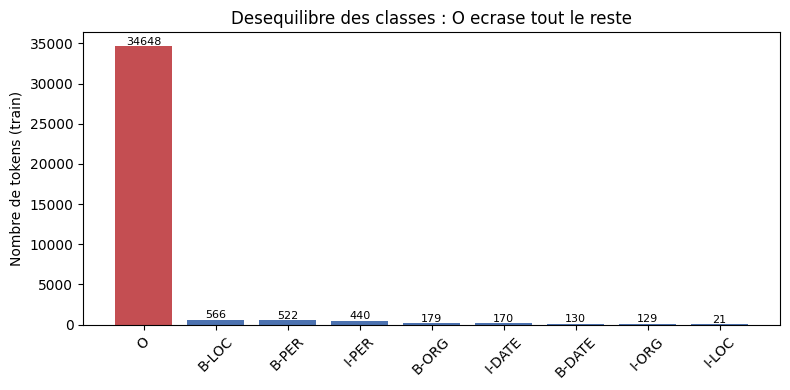

In [8]:
import matplotlib.pyplot as plt

# Desequilibre des classes (train)
c = Counter(l for x in data["train"] for l in x["labels"])
labels_sorted = ["O"] + sorted((k for k in c if k != "O"),
                               key=c.get, reverse=True)
vals = [c[l] for l in labels_sorted]
plt.figure(figsize=(8, 4))
bars = plt.bar(labels_sorted, vals,
               color=["#C44E52"] + ["#4C72B0"] * (len(labels_sorted) - 1))
plt.title("Desequilibre des classes : O ecrase tout le reste")
plt.ylabel("Nombre de tokens (train)")
plt.xticks(rotation=45)
for b, v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v+200, str(v), ha="center", fontsize=8)
plt.tight_layout(); plt.show()

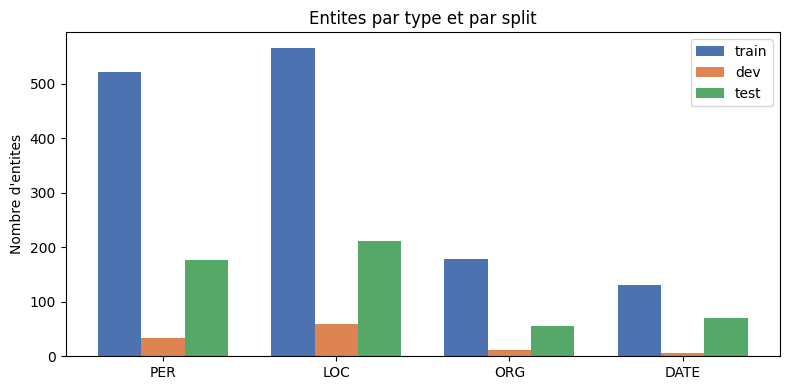

In [9]:
# Distribution des entites par type et par split
types = ["PER", "LOC", "ORG", "DATE"]
colors = {"train": "#4C72B0", "dev": "#DD8452", "test": "#55A868"}
width, x = 0.25, range(len(types))
plt.figure(figsize=(8, 4))
for i, s in enumerate(["train", "dev", "test"]):
    ents = [e for r in data[s] for e in extract_entities(r["labels"])]
    cc = Counter(t for t, _, _ in ents)
    plt.bar([p + i*width for p in x], [cc[t] for t in types], width,
            label=s, color=colors[s])
plt.xticks([p + width for p in x], types)
plt.ylabel("Nombre d'entites"); plt.title("Entites par type et par split")
plt.legend(); plt.tight_layout(); plt.show()

### Bilan de la Phase 1

- **Corpus petit** (~1900 phrases) → le *fine-tuning* d'un modele pre-entraine
  est indispensable (impossible d'entrainer de zero).
- **Fort desequilibre** (~94 % de `O`) → l'accuracy est trompeuse, d'ou
  l'evaluation au **F1 niveau entite**.
- **ORG et DATE rares** → seront les types les plus difficiles.
- **~49 % de mots inconnus** en test → un modele a **sous-mots** pre-entraine
  est le meilleur choix (il gere les mots jamais vus).
- **BIO propre** (0 incoherence) → pas de nettoyage necessaire.


## Phase 2 — Pipeline de donnees

On transforme phrases + labels en tenseurs pour le transformer, en gerant
**l'alignement labels ↔ sous-mots** (le point technique critique).


### 2.1 — Correspondance label ↔ entier

Le modele manipule des entiers, pas des chaines. On fige une table utilisee
dans **tout** le projet (sinon les etiquettes se decalent).


In [10]:
LABELS = ["O", "B-PER", "I-PER", "B-LOC", "I-LOC",
          "B-DATE", "I-DATE", "B-ORG", "I-ORG"]
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for l, i in label2id.items()}
print(label2id)

{'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-LOC': 3, 'I-LOC': 4, 'B-DATE': 5, 'I-DATE': 6, 'B-ORG': 7, 'I-ORG': 8}


### 2.2 — Construction du `DatasetDict` HuggingFace

In [11]:
from datasets import Dataset, DatasetDict

def load_split(path):
    sents = read_conll(path)
    return Dataset.from_dict({
        "tokens":  [s["tokens"] for s in sents],
        "ner_tags": [[label2id[l] for l in s["labels"]] for s in sents],
    })

ds = DatasetDict({
    "train":      load_split("train.txt"),
    "validation": load_split("dev.txt"),
    "test":       load_split("test.txt"),
})
print(ds)
print("\nExemple :", ds["train"][0])

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 1871
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 267
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 539
    })
})

Exemple : {'tokens': ['SAFIYETU', 'BÉEY', 'Céy', 'Koronaa', '!'], 'ner_tags': [1, 2, 0, 0, 0]}


### 2.3 — Chargement du tokenizer

`Davlan/afro-xlmr-base` est pre-entraine sur des langues africaines dont le
wolof — c'est le modele de reference du benchmark MasakhaNER. On peut aussi
tester `xlm-roberta-base` pour comparer.


In [12]:
from transformers import AutoTokenizer

MODEL_NAME = "Davlan/afro-xlmr-base"   # alternative : "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Illustration du decoupage en sous-mots sur un mot wolof
mot = "SAFIYETU"
print(mot, "->", tokenizer.tokenize(mot))

SAFIYETU -> ['▁', 'SAF', 'IYE', 'TU']


### 2.4 — Alignement des labels sur les sous-mots (fonction clef)

Regle : le **1er** sous-mot d'un mot recoit le vrai label ; les sous-mots
suivants et les tokens speciaux recoivent **-100** (ignore par la fonction
de cout).


In [13]:
def tokenize_and_align_labels(examples, max_length=256,
                              label_all_subwords=False):
    tokenized = tokenizer(
        examples["tokens"],
        truncation=True,
        max_length=max_length,
        is_split_into_words=True,   # on donne des MOTS deja separes
    )
    all_labels = []
    for i, labels in enumerate(examples["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        previous, label_ids = None, []
        for wid in word_ids:
            if wid is None:                 # CLS / SEP / PAD
                label_ids.append(-100)
            elif wid != previous:           # 1er sous-mot du mot
                label_ids.append(labels[wid])
            else:                           # sous-mot de continuation
                label_ids.append(labels[wid] if label_all_subwords else -100)
            previous = wid
        all_labels.append(label_ids)
    tokenized["labels"] = all_labels
    return tokenized

tokenized_ds = ds.map(tokenize_and_align_labels, batched=True,
                      remove_columns=ds["train"].column_names)
print(tokenized_ds)

Map:   0%|          | 0/1871 [00:00<?, ? examples/s]

Map:   0%|          | 0/267 [00:00<?, ? examples/s]

Map:   0%|          | 0/539 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1871
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 267
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 539
    })
})


### 2.5 — Verification : on inspecte un exemple aligne

In [14]:
ex = ds["train"][0]
enc = tokenizer(ex["tokens"], is_split_into_words=True)
out = tokenize_and_align_labels({"tokens": [ex["tokens"]],
                                 "ner_tags": [ex["ner_tags"]]})

sub_tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])
word_ids = enc.word_ids()
aligned = out["labels"][0]

print(f"{'sous-mot':<15}{'word_id':<9}{'label'}")
print("-" * 34)
for st, wid, lab in zip(sub_tokens, word_ids, aligned):
    lab_str = "-100" if lab == -100 else id2label[lab]
    print(f"{st:<15}{str(wid):<9}{lab_str}")

sous-mot       word_id  label
----------------------------------
<s>            None     -100
▁              0        B-PER
SAF            0        -100
IYE            0        -100
TU             0        -100
▁B             1        I-PER
É              1        -100
EY             1        -100
▁Cé            2        O
y              2        -100
▁Koro          3        O
na             3        -100
a              3        -100
▁!             4        O
</s>           None     -100


**Lecture attendue :** un mot decoupe en plusieurs sous-mots ne garde son
etiquette que sur le premier morceau ; les autres, ainsi que `<s>`/`</s>`,
portent `-100` et n'entrent pas dans le calcul de la perte.


## Phase 3 — Fine-tuning du modele

On assemble maintenant l'entrainement. Quatre briques :
1. un **DataCollator** qui complete (padding) les phrases par lot ;
2. le **modele** `AutoModelForTokenClassification` (une tete de classification
   par token posee sur afro-xlmr) ;
3. une fonction **`compute_metrics`** qui calcule le **F1 niveau entite** (seqeval) ;
4. le **`Trainer`** qui orchestre la boucle d'entrainement.


### 3.1 — DataCollator (padding dynamique)

Les phrases n'ont pas la meme longueur. Plutot que de tout completer a 256,
le collator complete chaque **lot** a la longueur de sa phrase la plus longue
(plus rapide). Il complete aussi les labels avec `-100`.


In [15]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

ImportError: Traceback (most recent call last):
  File "C:\Users\LENOVO LEGION\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: Une routine d’initialisation d’une bibliothèque de liens dynamiques (DLL) a échoué.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

### 3.2 — Chargement du modele

On charge afro-xlmr **avec une tete de classification de tokens** (9 sorties).
On lui passe `id2label`/`label2id` : ces tables seront sauvegardees avec le
modele et resserviront a l'inference (notamment dans l'app Streamlit).

> Un avertissement du type *"some weights were not initialized... you should
> train this model"* est **normal** : la tete de classification est neuve et
> c'est justement ce qu'on va entrainer.


In [ ]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id,
)

### 3.3 — Metrique : F1 au niveau entite (seqeval)

`seqeval` reconstruit les entites a partir du BIO puis compare. On retire
d'abord les positions `-100` (sous-mots de continuation et tokens speciaux),
et on retraduit les ids en etiquettes texte.


In [ ]:
import numpy as np
import evaluate

seqeval = evaluate.load("seqeval")

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)

    # On ne garde que les positions valides (label != -100)
    true_predictions = [
        [id2label[p] for p, l in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]
    true_labels = [
        [id2label[l] for p, l in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]

    results = seqeval.compute(predictions=true_predictions,
                              references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall":    results["overall_recall"],
        "f1":        results["overall_f1"],
        "accuracy":  results["overall_accuracy"],
    }

### 3.4 — Parametres d'entrainement

Choix adaptes a un petit corpus : learning rate faible (`2e-5`), plusieurs
epoques, et surtout `load_best_model_at_end` + `metric_for_best_model="f1"`
pour **garder le meilleur modele** (celui au meilleur F1 sur la validation)
et non le dernier. L'early stopping arrete si le F1 stagne.


In [ ]:
from transformers import TrainingArguments

args = TrainingArguments(
    output_dir="afro-xlmr-wolof-ner",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=15,
    weight_decay=0.01,
    eval_strategy="epoch",          # transformers < 4.41 : evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
)

### 3.5 — Le Trainer et l'entrainement

Le `Trainer` relie tout : modele, donnees, collator, metrique. `EarlyStopping`
coupe l'entrainement si le F1 de validation ne progresse plus pendant
3 evaluations.


In [ ]:
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    processing_class=tokenizer,     # transformers < 5 : utiliser tokenizer=tokenizer
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

### 3.6 — Sauvegarde du modele

On sauvegarde le meilleur modele et son tokenizer : ils resserviront pour
l'evaluation (Phase 4) et l'application Streamlit (Phase 6).


In [ ]:
trainer.save_model("afro-xlmr-wolof-ner")
tokenizer.save_pretrained("afro-xlmr-wolof-ner")
print("Modele sauvegarde dans ./afro-xlmr-wolof-ner")

# Sur Colab, pour telecharger le modele en .zip :
# !zip -r afro-xlmr-wolof-ner.zip afro-xlmr-wolof-ner
# from google.colab import files; files.download("afro-xlmr-wolof-ner.zip")

### A propos du desequilibre des classes

Le `Trainer` utilise par defaut l'entropie croisee, qui gere deja correctement
le desequilibre grace au masquage `-100` et a l'evaluation au niveau entite.
**Piste d'amelioration a mentionner au jury :** on pourrait ponderer la perte
(donner plus de poids aux classes rares comme ORG/DATE) en sous-classant le
`Trainer` pour utiliser une `CrossEntropyLoss(weight=...)`. C'est un bon point
de discussion sur les limites du modele.

### Prochaine etape — Phase 4 (evaluation)
On evaluera le meilleur modele sur le **test** avec `trainer.predict`, on
affichera le **rapport seqeval par type d'entite** (on verra si ORG/DATE sont
bien les plus faibles, comme anticipe en Phase 1), et une matrice de confusion.
